# Week 5 (Dimension Reduction, SVM)

## Dimension Reduction

### `make_regression`을 이용한 PCA Regression

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html

scikit-learn에서는 `make_regression` 함수를 이용하여 회귀분석을 연습하기 위한 데이터셋을 만들 수 있다. 이를 이용해서 Principal Component Regression을 연습하는 과제를 진행해보자.

In [67]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression

### Q1 `make_regression` 함수로 데이터를 생성해보자

독립변수는 X1부터 X10까지, 종속변수는 Y를 생성하자. 표본 크기는 1000으로 설정하고, `noise`, `random_state`, `bias`등의 변수는 자유롭게 설정해보자.

In [68]:
# make_regression로 데이터 생성
X, y=make_regression(
    n_samples=1000,
    n_features=10,
    noise=20,
    random_state=42,
    bias=50
)

columns=[f'X{i}' for i in range(1, 11)]
df=pd.DataFrame(X, columns=columns)
df['y']=y

### Q2 EDA를 해보자

각 변수별 히스토그램, scatterplot matrix, correlation matrix, 요약통계량(descriptive statistics)를 그려보자


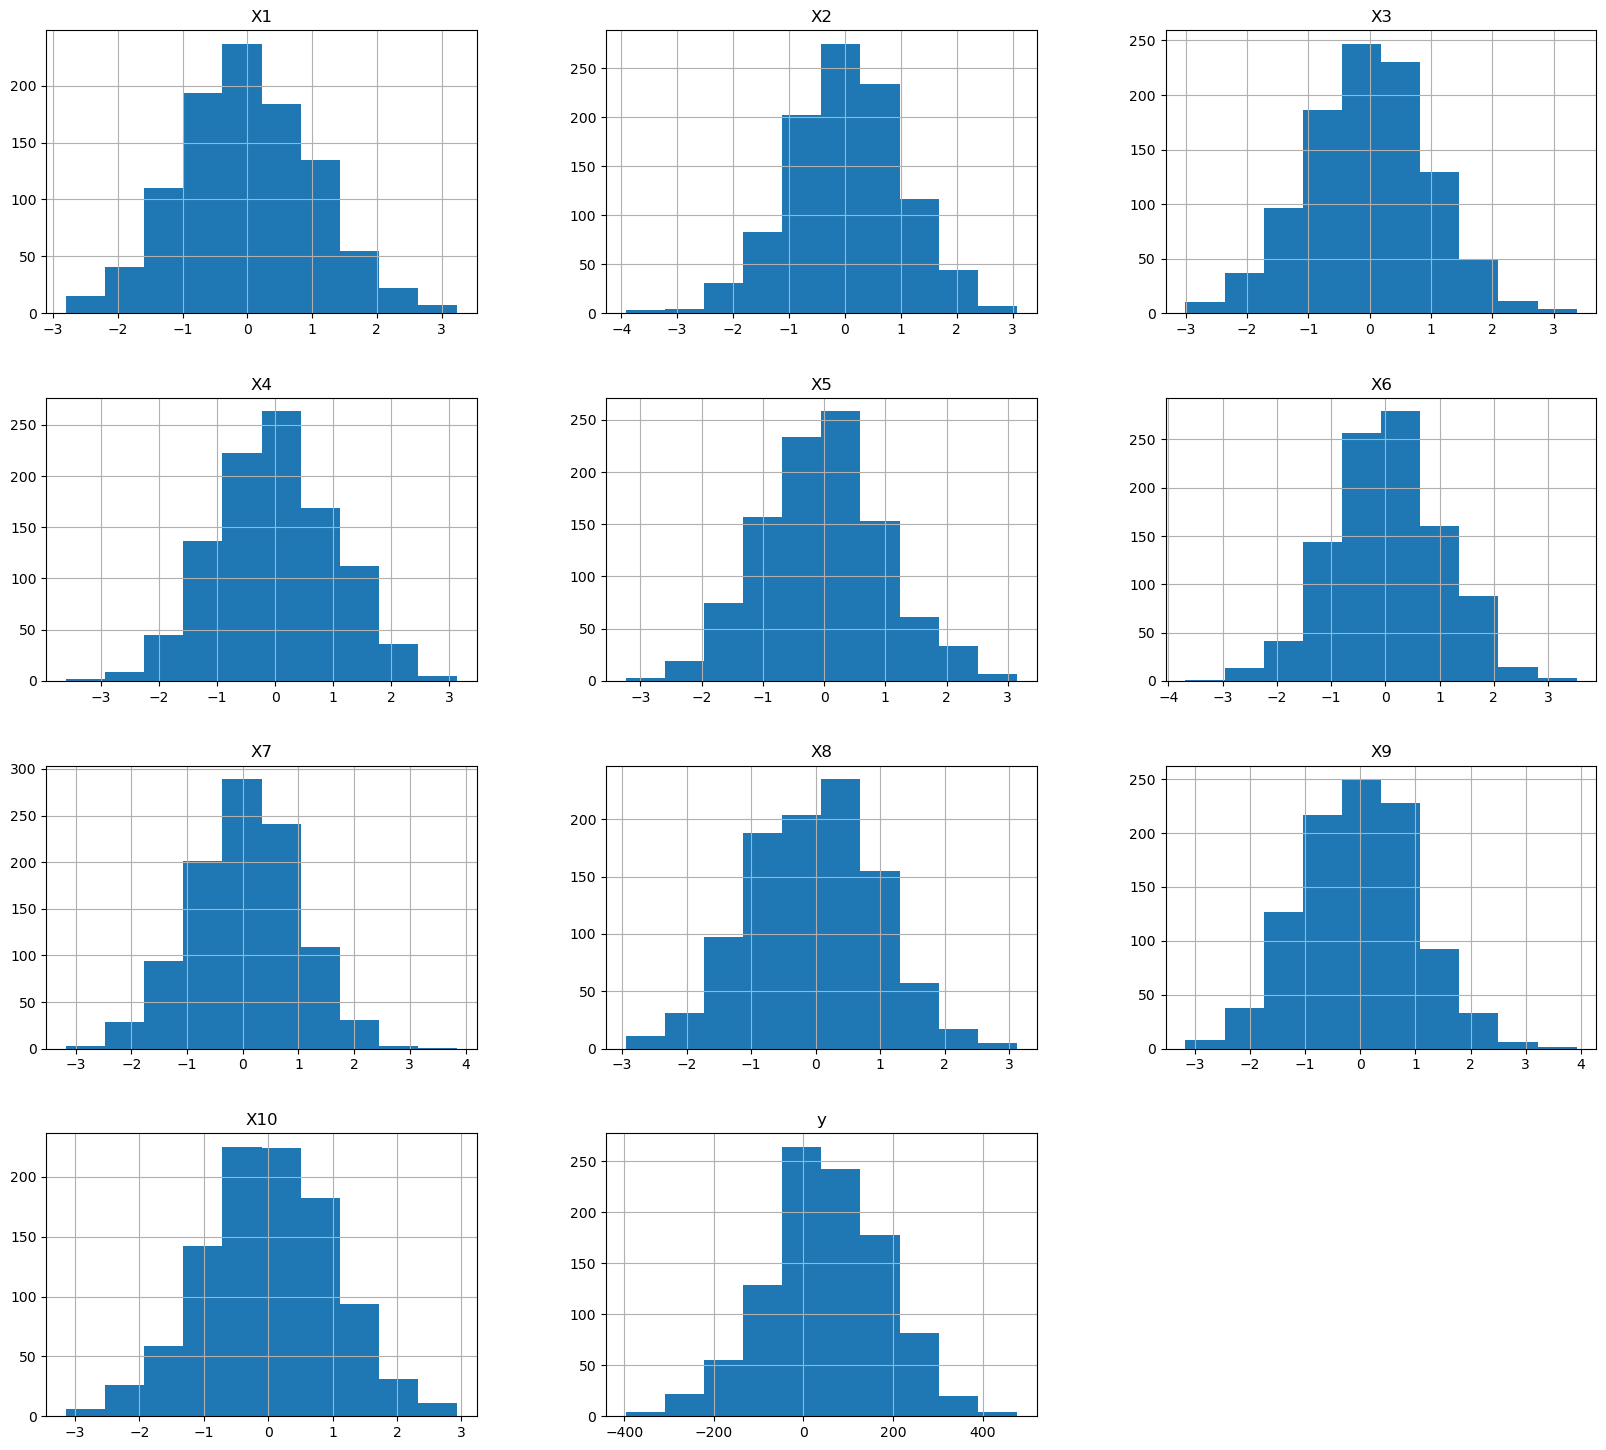

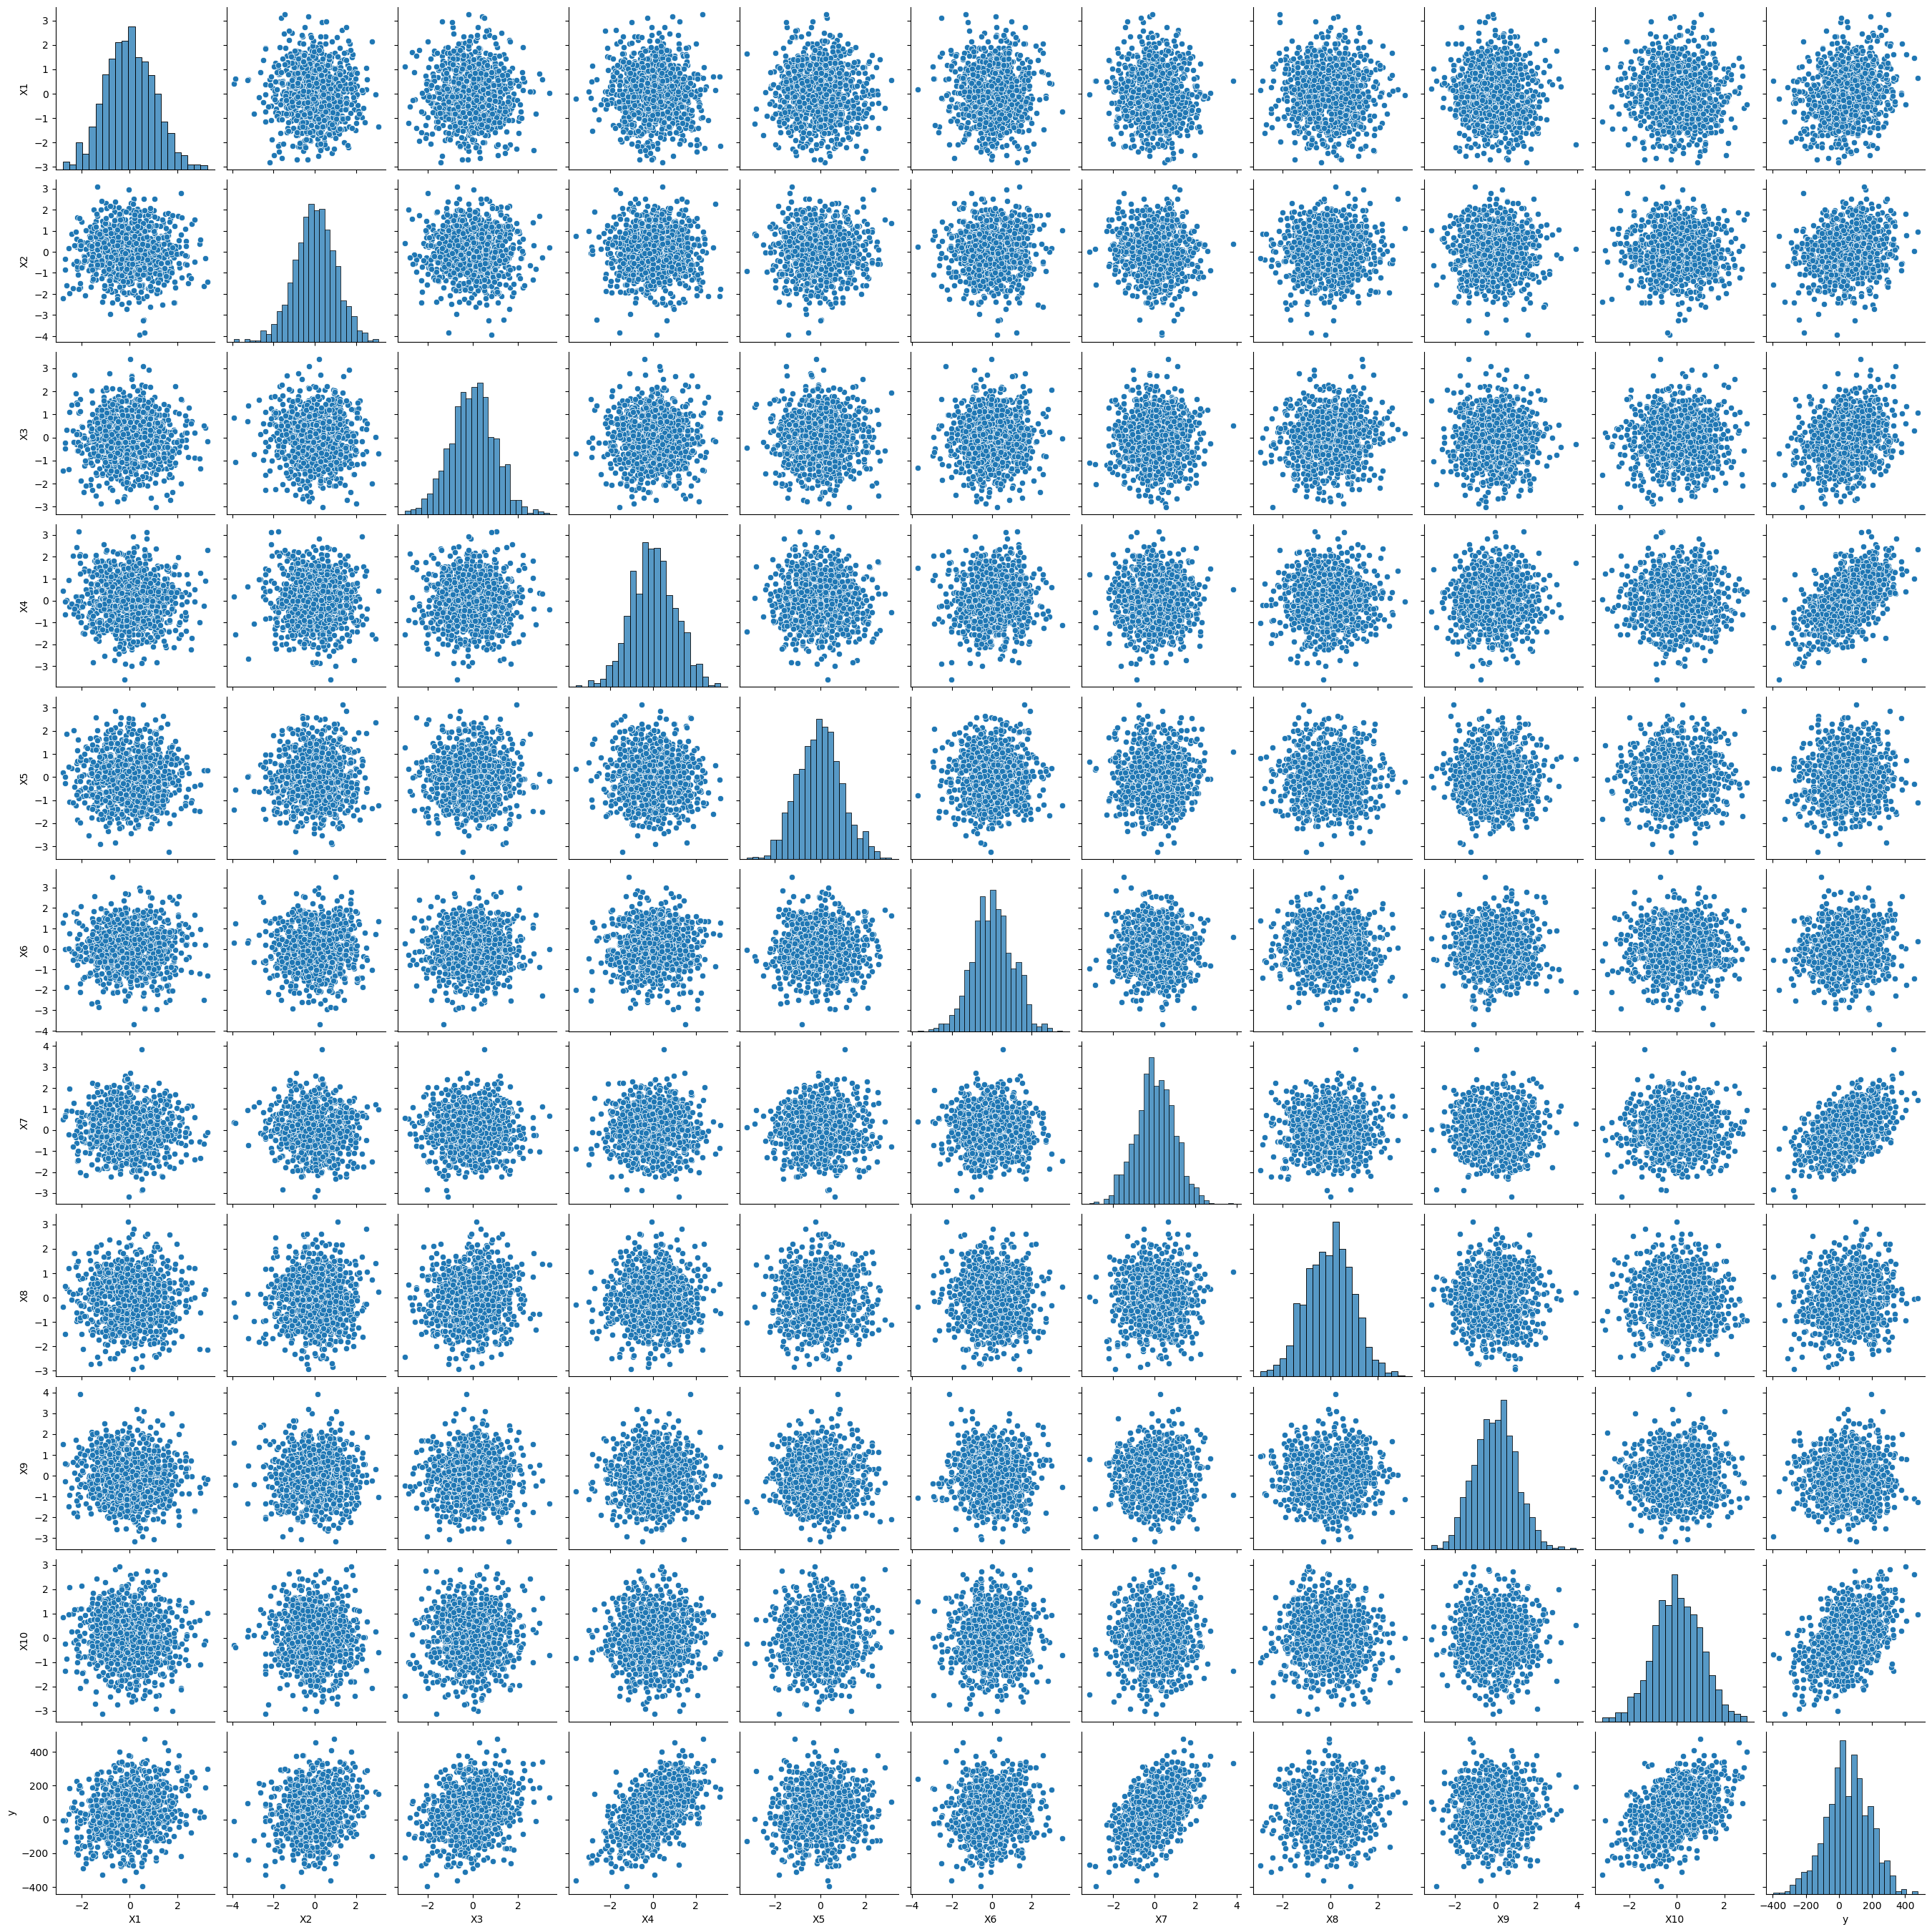

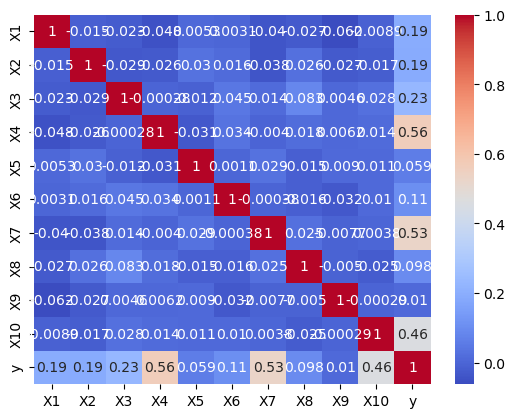

                X1           X2           X3           X4           X5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     -0.002689     0.010788    -0.023104     0.005495    -0.022542   
std       1.031230     1.005433     0.986846     1.030962     0.983366   
min      -2.801912    -3.922400    -3.007632    -3.601085    -3.241267   
25%      -0.744779    -0.616527    -0.650034    -0.713176    -0.702626   
50%      -0.024976     0.014006    -0.003221    -0.013284    -0.015036   
75%       0.683319     0.679698     0.608861     0.696602     0.613766   
max       3.243093     3.076860     3.377383     3.137749     3.152057   

                X6           X7           X8           X9          X10  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.031292     0.038105    -0.043075    -0.029252     0.013622   
std       1.016046     0.945284     0.983406     1.037024     1.012645   
min      -3.688365    -3.176704    -2

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# 히스토그램
df.hist(figsize=(20, 18))

# Scatterplot matrix
sns.pairplot(df, diag_kind='hist')
plt.show()

# Correlation matrix
corr=df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# 요약 통계량
print(df.describe())

### Q3 `StandardScaler` 로 scaling을 해보자

X 변수들에 대해 `StandarScaler`를 이용하여 표준화를 해보자.
PCA를 하기 전에 스케일링을 한다는 점을 유의하자.

In [70]:
from sklearn.preprocessing import StandardScaler

# 스케일링하기
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

### Q4 `PCA`를 해보자

`PCA` 함수를 이용하여 PCA를 해보자. 또 다음을 해보자.

- PC1 부터 PC10 까지 Scree plot을 그려보자
- PC1과 PC2를 가지고 scatterplot을 그려보자.

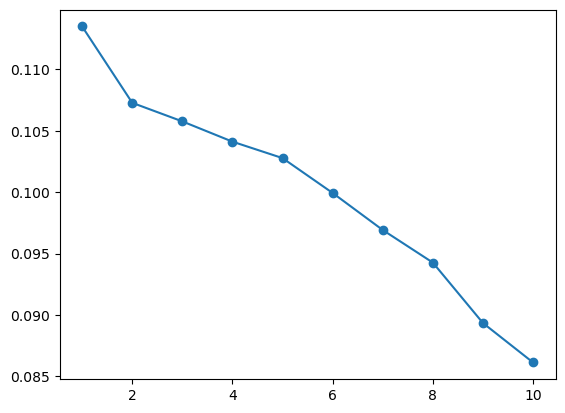

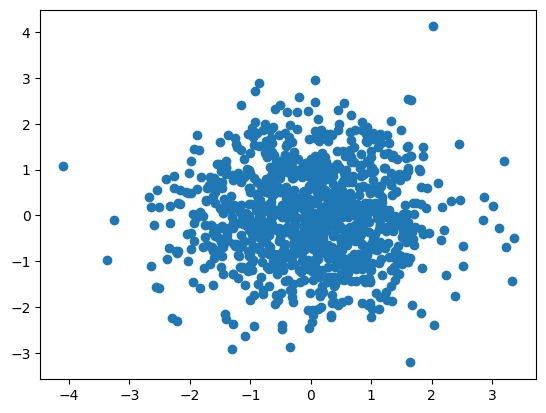

In [71]:
from sklearn.decomposition import PCA

# PCA 계산하기
pca = PCA(n_components=10)
X_pca=pca.fit_transform(X_scaled)

pc_cols=[f'PC{i}' for i in range(1, 11)]
pca_df=pd.DataFrame(X_pca, columns=pc_cols)
pca_df.head()

# Scree plot 그리기
explained_var=pca.explained_variance_ratio_
plt.figure()
plt.plot(range(1, 11), explained_var, marker='o')
plt.show()

# PC1 와 PC2 산점도 그리기
plt.figure()
plt.scatter(pca_df.PC1, pca_df.PC2)
plt.show()

### Q5 `train_test_split`을 해보자

Train set과 Test set을 6:4 비율로 나눠보자

In [72]:
from sklearn.model_selection import train_test_split

# train set과 test set 나누기
X=pca_df
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.4, random_state=42)

###  Q6 Principal Component Regression을 진행해보자.

Q5에서 만든 데이터로부터 다음의 과정으로 문제를 풀어보자.
- Y를 종속변수(`y_train`), `X_train`의 PC1을 종속변수로 하여 Linear Regression을 적합한다.
- `y_pred`과 `y_train`을 비교하여 train error의 MSE를 구한다.
- Principal component을 하나 늘려 Linear regression을 적합한다. 즉 Y에 대해 PC1, PC2으로 Linear Regression을 적합한다.
- 마찬가지로 train error의 MSE를 구한다.
- PC10까지 같은 과정을 반복하고, MSE를 비교한다.



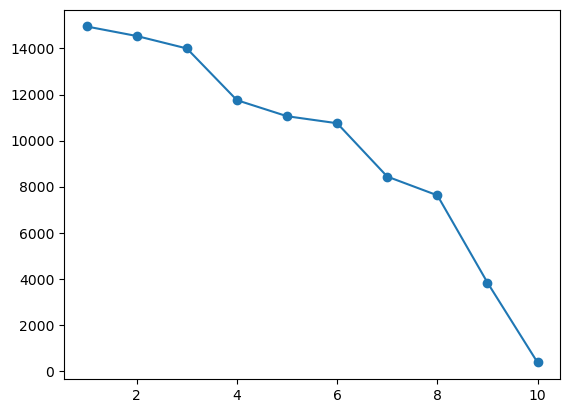

PC 1 ~ PC 1 사용 → Train MSE: 14955.6113
PC 1 ~ PC 2 사용 → Train MSE: 14541.8007
PC 1 ~ PC 3 사용 → Train MSE: 14001.2756
PC 1 ~ PC 4 사용 → Train MSE: 11755.0409
PC 1 ~ PC 5 사용 → Train MSE: 11058.4883
PC 1 ~ PC 6 사용 → Train MSE: 10753.9847
PC 1 ~ PC 7 사용 → Train MSE: 8437.6110
PC 1 ~ PC 8 사용 → Train MSE: 7624.3928
PC 1 ~ PC 9 사용 → Train MSE: 3834.3814
PC 1 ~ PC 10 사용 → Train MSE: 365.7927


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# train MSE 저장
mse_train = []
for k in range(1, 11):
    X_train_k=X_train.iloc[:, :k]

    model=LinearRegression()
    model.fit(X_train_k, y_train)

    y_pred_train=model.predict(X_train_k)
    mse=mean_squared_error(y_train, y_pred_train)

    mse_train.append(mse)

plt.figure()
plt.plot(range(1, 11), mse_train, marker='o')
plt.show()

for i, mse in enumerate(mse_train, start=1):
    print(f"PC 1 ~ PC {i} 사용 → Train MSE: {mse:.4f}")

# 회귀모형 적합
model=LinearRegression()
model.fit(X_train, y_train)

### Q7 Test error을 계산해보자.

위 과정에서 적합한 모형을 바탕으로 `y_test`을 추정하고 `y_test`와의 MSE를 계산하여 test error을 구해보자.

In [79]:
# test MSE 저장
mse_test = []
y_pred_test=model.predict(X_test)
mse=mean_squared_error(y_test, y_pred_test)
mse

396.9883283210191

## SVM

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.svm import SVC, SVR

- SVC (Classification)
- SVR (Regression)

### 1.1 Hard Margin Classifier

#### Q1.1 Hard Margin Classifier란? :

데이터 오분류를 허용하지 않는 분류기

In [81]:
# 데이터셋 생성
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8]])
y = np.array([0, 0, 0, 1, 1, 1])

#### Q1.2 위 데이터셋을 2차원의 좌표평면에 시각화해주세요.

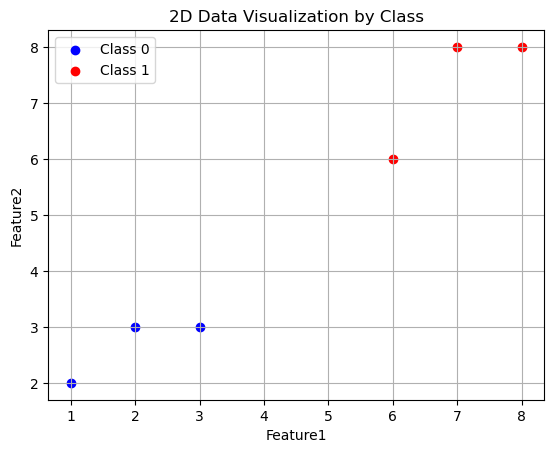

In [82]:
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Class 1')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title('2D Data Visualization by Class')
plt.legend()
plt.grid()
plt.show()

In [83]:
# Hard Margin SVM 모델 학습
model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

,C,10000000000.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Q1.3 하단 w와 b는 모델 학습으로 찾아낸 Wx+b의 계수와 상수항입니다. w와 b를 정의해주세요.

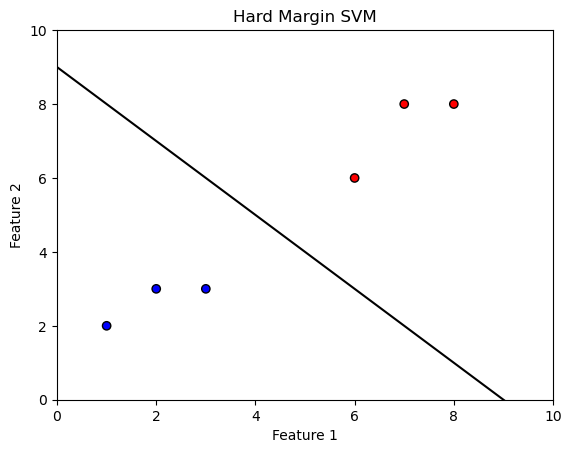

In [84]:
# 결정 경계 시각화
w = model.coef_[0]
b = model.intercept_[0]
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hard Margin SVM')
plt.show()

### 1.2 Soft Margin Classifier

#### Q2.1 Soft Margin Classifier란?

데이터 오분류를 허용하는 분류기

#### Q2.2 Soft Margin의 정의를 떠올리며, 노이즈가 추가된 데이터셋을 생성해주세요. (2개 이상 추가 생성 필요)

In [85]:
# 데이터셋 생성 (약간의 노이즈 추가)
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8], [1, 1], [2, 2]])
y = np.array([0, 0, 0, 1, 1, 1, 1, 1])

In [86]:
# Soft Margin SVM 모델 학습
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Q2.3 마진을 산출해 시각화하고, Support Vector을 찾아주세요.

하단 그림은 예시로, 꼭 똑같이 출력되지 않아도 됩니다.

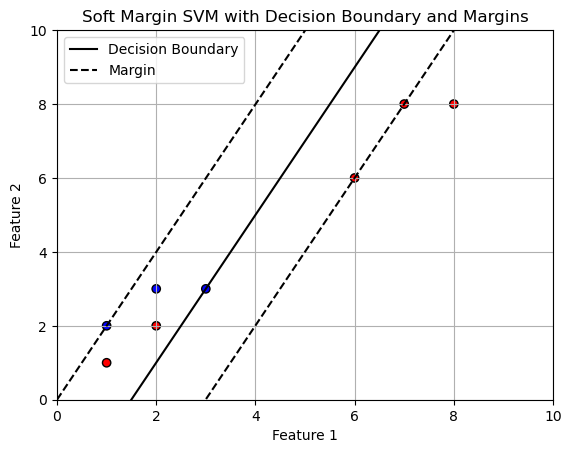

In [87]:
# 결정 경계 시각화
w =model.coef_[0]
b =model.intercept_[0]
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

# 마진 경계 계산
# margin =
y_margin_positive =-(w[0]*x_plot+b-1)/w[1]
y_margin_negative =-(w[0]*x_plot+b+1)/w[1]

# 마진 시각화
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-', label='Decision Boundary')
plt.plot(x_plot, y_margin_positive, 'k--', label='Margin')
plt.plot(x_plot, y_margin_negative, 'k--')

plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Soft Margin SVM with Decision Boundary and Margins')
plt.legend()
plt.grid(True)
plt.show()

### 1.3 프로젝트 (SVC)

In [88]:
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

#### **Linear SVC**

In [89]:
iris = load_iris()

X = iris.data[:, :2]
y = iris.target

C = 1
clf = SVC(kernel = "linear", C=C)
clf.fit(X,y)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [90]:
y_pred = clf.predict(X) # 학습 데이터의 재예측 (실습용)
confusion_matrix(y, y_pred) # 따라서, 분류 결과가 상당히 정확할 수밖에 없음을 감안해야 함

array([[50,  0,  0],
       [ 0, 38, 12],
       [ 0, 15, 35]])

#### Q3.1 위 예시처럼, 옵션을 linear로 설정해도 되지만, sklearn의 LinearSVC 함수를 사용해도 구현할 수 있습니다. LinearSVC로 재구현해주세요.

In [91]:
from sklearn.svm import LinearSVC

model=LinearSVC(C=1)
model.fit(X, y)
y_pred=model.predict(X)
confusion_matrix(y, y_pred)

array([[49,  1,  0],
       [ 2, 30, 18],
       [ 0,  9, 41]])

#### **Kernal SVC**

#### Q3.2 Kernel SCV - non-linear한 형태의 SVM을 하나 이상 구현해주세요. 동일하게, 학습데이터를 predict하여 confusion matrix를 구해주세요.

In [98]:
model_rbf=SVC(kernel='rbf', C=1, gamma='scale')
model_rbf.fit(X, y)
y_pred=model_rbf.predict(X)
confusion_matrix(y, y_pred)

array([[50,  0,  0],
       [ 0, 38, 12],
       [ 0, 15, 35]])

#### 시각화

#### Q3.3 아래 예시 plot처럼, linear model과 non-linear 모델의 시각화 결과를 출력해주세요.

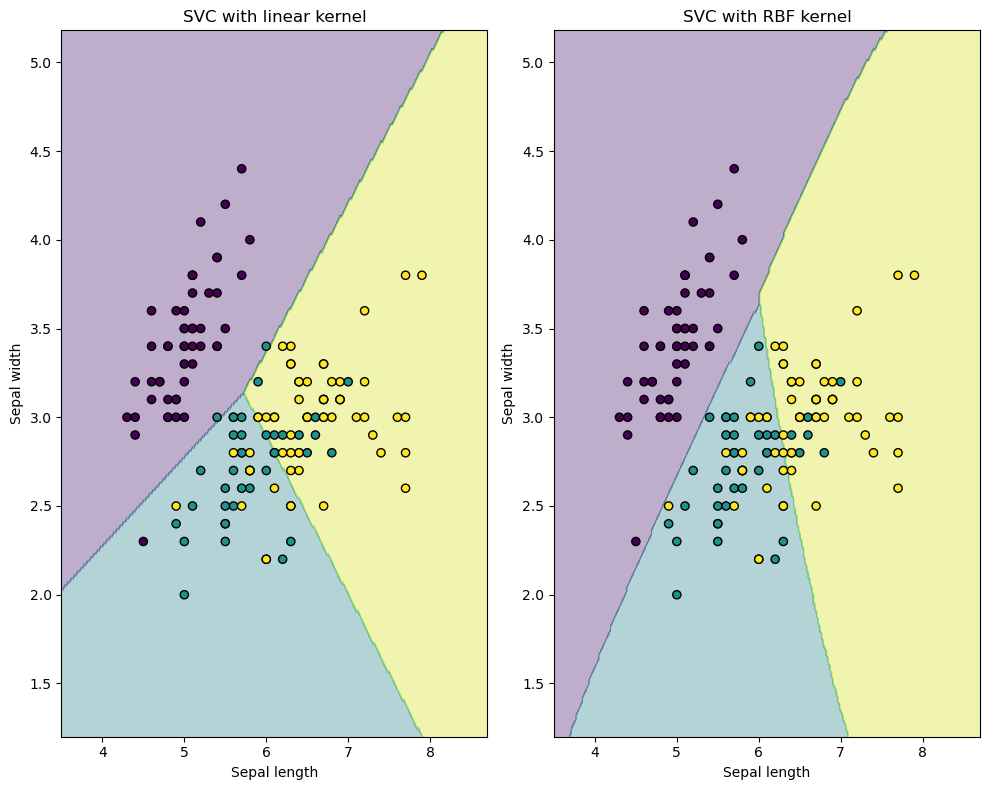

In [99]:
def make_meshgrid(X, step=0.02, pad=0.8):
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    return xx, yy

def plot_decision_regions(ax, clf, X, y, title):
    xx, yy = make_meshgrid(X)
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35) 
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=35) 
    ax.set_title(title)
    ax.set_xlabel('Sepal length')
    ax.set_ylabel('Sepal width')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

models = [
    ('SVC with linear kernel', model),
    ('SVC with RBF kernel', model_rbf)
]

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (title, clf) in zip(axes, models):
    clf.fit(X, y)
    plot_decision_regions(ax, clf, X, y, title)

plt.tight_layout()
plt.show()

plt.show()